In [40]:
# Install required libraries

!pip install xgboost -q

 Import required libraries

In [41]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

Upload and load the dataset


In [42]:


df = pd.read_csv("Country-data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Clean dataset and handle missing values

In [43]:


df.columns = df.columns.str.strip()

df = df.drop_duplicates()

for col in df.columns:
    if col != "country":
        df[col] = pd.to_numeric(df[col], errors="coerce")

for col in df.columns:
    if col != "country":
        df[col] = df[col].fillna(df[col].median())

print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


 Separate features and scale the data

In [44]:


countries = df["country"]

X = df.drop("country", axis=1)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(167, 9)


Find optimal clusters using Elbow Method

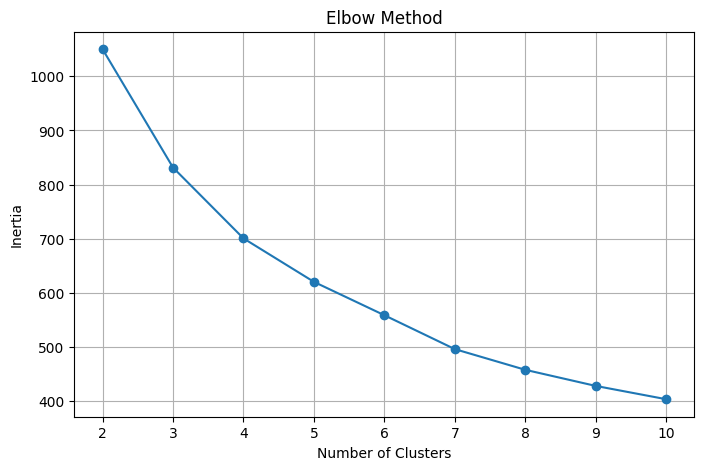

In [45]:


inertia = []

k_values = range(2, 11)

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

plt.figure(figsize=(8,5))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

Train K-Means clustering model

In [46]:


best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

df["KMeans_Cluster"].value_counts()

,count
KMeans_Cluster,
2,84
1,47
0,36


Evaluate clustering using Silhouette Score

In [47]:


score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", round(score, 4))

Silhouette Score: 0.2833


Build DBSCAN clustering model

In [48]:


dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = dbscan_labels

df["DBSCAN_Cluster"].value_counts()

,count
DBSCAN_Cluster,
0,137
-1,30


Reduce dimensions using PCA

In [49]:


pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

df["PCA1"] = pca_features[:, 0]
df["PCA2"] = pca_features[:, 1]

df[["PCA1", "PCA2"]].head()

,PCA1,PCA2
0,-2.913025,0.095621
1,0.429911,-0.588156
2,-0.285225,-0.455174
3,-2.932423,1.695555
4,1.033576,0.136659


Visualize K-Means clusters in two dimensions

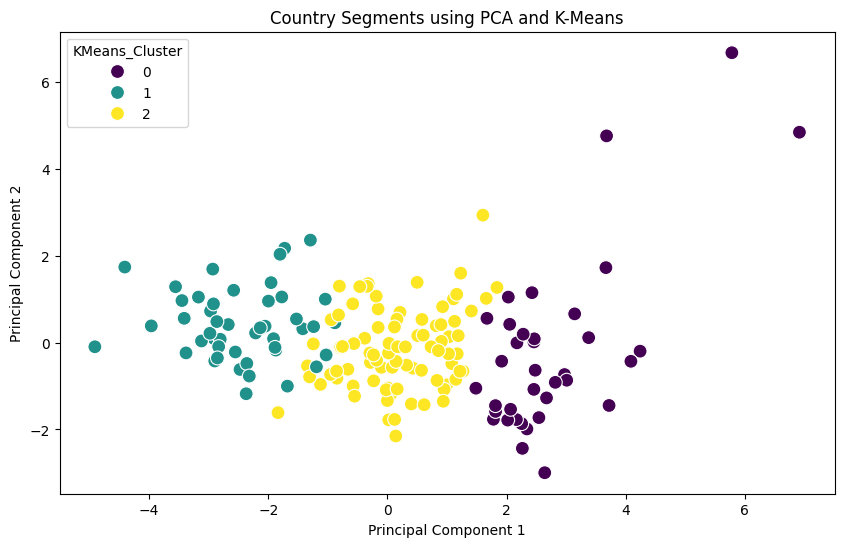

In [50]:


plt.figure(figsize=(10,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="KMeans_Cluster",
    palette="viridis",
    data=df,
    s=100
)

plt.title("Country Segments using PCA and K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Create target labels from K-Means clusters

In [51]:


y = kmeans_labels

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

 Train Random Forest classifier

In [52]:


rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9705882352941176


Train XGBoost classifier

In [53]:


xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.9705882352941176


Identify important features using Random Forest

In [54]:


importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
0,child_mort,0.273986
8,gdpp,0.188719
6,life_expec,0.165663
7,total_fer,0.153669
4,income,0.150858
2,health,0.031239
5,inflation,0.014584
1,exports,0.014407
3,imports,0.006875


Visualize top important features

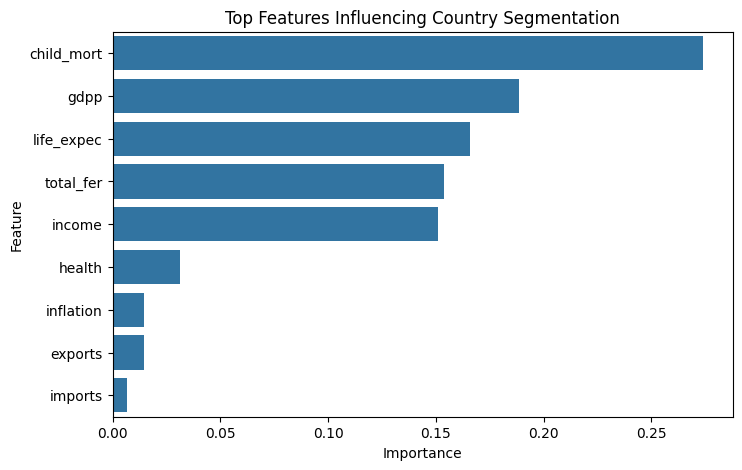

In [55]:


plt.figure(figsize=(8,5))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top Features Influencing Country Segmentation")
plt.show()

Generate cluster-wise socio-economic summary


In [56]:

cluster_summary = df.groupby(
    "KMeans_Cluster"
)[X.columns].mean()

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


# Section 14: Socio-Economic Observations

1. K-Means clustering successfully divided countries into three distinct groups based on socio-economic and health indicators.

2. One cluster contained highly developed countries characterized by high income levels, low child mortality, and high life expectancy.

3. Another cluster represented developing nations with moderate economic performance and improving health indicators.

4. The least developed cluster showed lower income levels, higher child mortality rates, and reduced life expectancy, indicating greater developmental challenges.

5. The clustering results reveal significant disparities in economic growth, healthcare quality, and living standards across countries, providing valuable insights for policy planning and resource allocation.


# Conclusion

* Successfully preprocessed and analyzed the country dataset using machine learning techniques.
* Applied K-Means and DBSCAN to identify meaningful country segments based on socio-economic indicators.
* Used PCA to visualize high-dimensional data and clearly distinguish country groups.
* Evaluated clustering quality using the Silhouette Score, confirming effective cluster formation.
* Trained Random Forest and XGBoost models to predict cluster membership with high accuracy.
* XGBoost achieved the best classification performance, while K-Means provided the most interpretable clustering results.
* The project demonstrated how data-driven approaches can support country development analysis and strategic decision-making.
